# 📏 Níveis de Medida em Python


Nesta aula, vamos aprender os principais **níveis de medida** e como isso impacta a análise de dados em Python.

🎯 Objetivos
- Identificar os 4 níveis de medida
- Entender o que pode e o que não pode ser feito com cada tipo de variável
- Aplicar isso em um dataset simulado de saúde
- Criar tabelas e gráficos simples para interpretar cada caso

# 🧠 Por que isso importa?


Antes de calcular média, mediana, frequências ou fazer gráficos, precisamos entender **que tipo de variável estamos analisando**.

Os níveis de medida ajudam a responder perguntas como:

- Posso ordenar essa variável?
- Posso calcular média?
- Faz sentido falar em diferença?
- Existe zero real?

Essa lógica se conecta com a aula de categorização e binarização, que mostra como variáveis contínuas podem ser agrupadas em categorias e até em duas classes, quando isso fizer sentido analítico fileciteturn0file0.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# 🏥 Criando um dataset simulado de saúde


Vamos construir um pequeno conjunto de dados com exemplos de variáveis:
- **Nominal**: sexo, tipo sanguíneo
- **Ordinal**: nível de dor, classificação de risco
- **Intervalar**: temperatura corporal em °C
- **Razão**: idade, peso, número de consultas, dias de internação

In [13]:
n = 120

df = pd.DataFrame({
    "sexo": np.random.choice(["F", "M"], size=n, p=[0.58, 0.42]),
    "tipo_sanguineo": np.random.choice(["A", "B", "AB", "O"], size=n, p=[0.36, 0.10, 0.05, 0.49]),
    "nivel_dor": np.random.choice(["Leve", "Moderada", "Intensa"], size=n, p=[0.45, 0.35, 0.20]),
    "classificacao_risco": np.random.choice(["Verde", "Amarelo", "Laranja", "Vermelho"], size=n, p=[0.45, 0.30, 0.18, 0.07]),
    "temperatura_c": np.round(np.random.normal(loc=36.8, scale=0.7, size=n), 1),
    "idade": np.random.randint(18, 91, size=n),
    "peso_kg": np.round(np.random.normal(loc=72, scale=14, size=n), 1),
    "num_consultas_ano": np.random.poisson(lam=4, size=n),
    "dias_internacao": np.random.poisson(lam=2, size=n)
})

df["peso_kg"] = df["peso_kg"].clip(lower=38)
df["temperatura_c"] = df["temperatura_c"].clip(lower=34.5, upper=40.5)

df.head()

,sexo,tipo_sanguineo,nivel_dor,classificacao_risco,temperatura_c,idade,peso_kg,num_consultas_ano,dias_internacao
0,F,O,Intensa,Verde,37.8,51,75.3,0,1
1,M,O,Intensa,Amarelo,37.5,25,82.8,1,1
2,M,A,Intensa,Amarelo,38.3,57,51.3,1,0
3,M,A,Leve,Amarelo,36.3,59,88.0,5,3
4,F,A,Leve,Vermelho,37.4,58,76.7,4,3


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   sexo                 120 non-null    object 
 1   tipo_sanguineo       120 non-null    object 
 2   nivel_dor            120 non-null    object 
 3   classificacao_risco  120 non-null    object 
 4   temperatura_c        120 non-null    float64
 5   idade                120 non-null    int64  
 6   peso_kg              120 non-null    float64
 7   num_consultas_ano    120 non-null    int64  
 8   dias_internacao      120 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 8.6+ KB


In [15]:
df.describe(include="all")

,sexo,tipo_sanguineo,nivel_dor,classificacao_risco,temperatura_c,idade,peso_kg,num_consultas_ano,dias_internacao
count,120,120,120,120,120.000000,120.000000,120.000000,120.000000,120.000000
unique,2,4,3,4,NaN,NaN,NaN,NaN,NaN
top,F,O,Leve,Verde,NaN,NaN,NaN,NaN,NaN
freq,71,59,49,54,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,36.812500,52.525000,72.616667,3.925000,1.858333
std,NaN,NaN,NaN,NaN,0.773355,22.204157,14.244275,2.013244,1.451142
min,NaN,NaN,NaN,NaN,35.200000,18.000000,38.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,36.275000,31.750000,64.375000,2.000000,1.000000
50%,NaN,NaN,NaN,NaN,36.800000,52.500000,71.950000,4.000000,2.000000
75%,NaN,NaN,NaN,NaN,37.325000,73.250000,82.025000,5.000000,3.000000


# 🟢 Nível nominal


**O que é?**
* Variáveis **nominais** representam categorias **sem ordem natural**.

**Exemplos**
- Sexo
- Tipo sanguíneo
- Diagnóstico
- Município
- Especialidade médica

**O que faz sentido?**
- Contagem
- Frequência relativa
- Moda
- Gráfico de barras

**O que não faz sentido?**
- Média
- Mediana numérica
- Dizer que uma categoria é maior que outra

In [16]:
df["sexo"].value_counts()

,count
sexo,
F,71
M,49


In [17]:
(df["sexo"].value_counts(normalize=True) * 100).round(1)

,proportion
sexo,
F,59.2
M,40.8


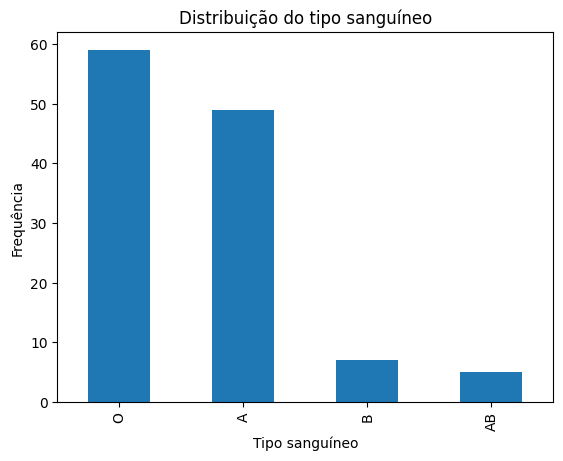

In [18]:
df["tipo_sanguineo"].value_counts().plot(kind="bar")
plt.title("Distribuição do tipo sanguíneo")
plt.xlabel("Tipo sanguíneo")
plt.ylabel("Frequência")
plt.show()

⚠️ **Erro comum**

Transformar categorias em números e achar que isso cria uma variável quantitativa.

In [19]:
mapa_sexo = {"F": 1, "M": 2}
df["sexo_codificado"] = df["sexo"].map(mapa_sexo)

df[["sexo", "sexo_codificado"]].head()

,sexo,sexo_codificado
0,F,1
1,M,2
2,M,2
3,M,2
4,F,1


Mesmo depois de codificar, a variável continua sendo **nominal**.  
O número serve para o computador, não para dizer que 2 é maior ou melhor que 1.

# 🟡 Nível ordinal


**O que é?**
* Variáveis **ordinais** têm **ordem**, mas a distância entre as categorias não é conhecida com precisão.

**Exemplos**
- Dor: leve, moderada, intensa
- Classificação de risco
- Satisfação: ruim, regular, boa, excelente
- Estadiamento clínico em categorias

**O que faz sentido?**
- Ordenar
- Frequências
- Mediana categórica
- Percentis em alguns contextos

**O que pede cuidado?**
- Média numérica, especialmente quando os intervalos entre categorias não são equivalentes

In [20]:
ordem_dor = ["Leve", "Moderada", "Intensa"]
df["nivel_dor"] = pd.Categorical(df["nivel_dor"], categories=ordem_dor, ordered=True)

df["nivel_dor"].value_counts().sort_index()

,count
nivel_dor,
Leve,49
Moderada,47
Intensa,24


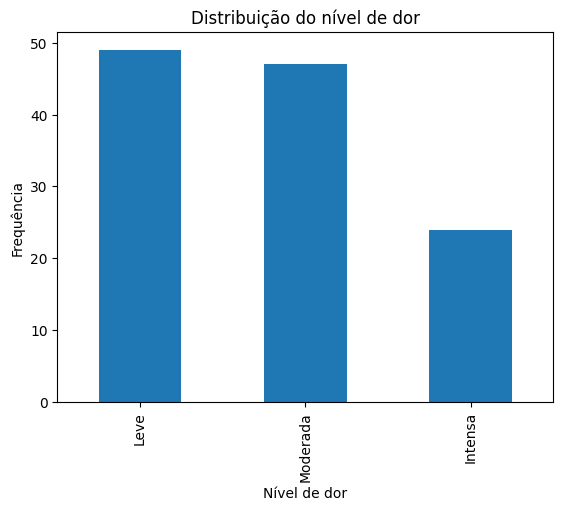

In [21]:
df["nivel_dor"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribuição do nível de dor")
plt.xlabel("Nível de dor")
plt.ylabel("Frequência")
plt.show()

In [22]:
ordem_risco = ["Verde", "Amarelo", "Laranja", "Vermelho"]
df["classificacao_risco"] = pd.Categorical(
    df["classificacao_risco"],
    categories=ordem_risco,
    ordered=True
)

df["classificacao_risco"].value_counts().sort_index()

,count
classificacao_risco,
Verde,54
Amarelo,25
Laranja,27
Vermelho,14


💡 **Exemplo de interpretação**


Sabemos que:
- Verde vem antes de amarelo
- Amarelo vem antes de laranja
- Laranja vem antes de vermelho

Mas não sabemos se a distância entre verde e amarelo é igual à distância entre amarelo e laranja.\

# 🔵 Nível intervalar



**O que é?**
Variáveis intervalares têm:
- ordem
- diferenças comparáveis
- Mas **não têm zero absoluto**.

**Exemplo clássico**
- Temperatura em °C

**O que faz sentido?**
- Média
- Desvio padrão
- Diferença entre valores
- Histograma

**O que não faz sentido?**
- Razões do tipo “40°C é o dobro de 20°C”

In [23]:
df["temperatura_c"].describe()

,temperatura_c
count,120.000000
mean,36.812500
std,0.773355
min,35.200000
25%,36.275000
50%,36.800000
75%,37.325000
max,39.000000


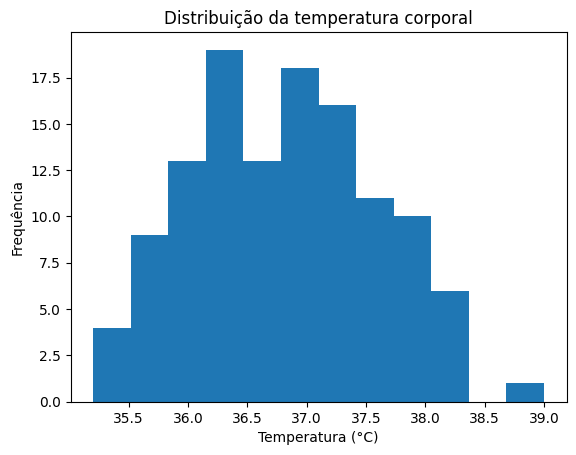

In [24]:
df["temperatura_c"].plot(kind="hist", bins=12)
plt.title("Distribuição da temperatura corporal")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frequência")
plt.show()

In [25]:
media_temp = df["temperatura_c"].mean()
desvio_temp = df["temperatura_c"].std()

print(f"Média da temperatura: {media_temp:.2f} °C")
print(f"Desvio padrão da temperatura: {desvio_temp:.2f}")

Média da temperatura: 36.81 °C
Desvio padrão da temperatura: 0.77


⚠️ **Interpretação importante**
A diferença entre 36°C e 38°C é de 2°C.  
Isso faz sentido. Mas dizer que 40°C é o dobro de 20°C não faz sentido físico nesse sistema de medida.

# 🔴 Nível razão


**O que é?**
Variáveis de razão têm:
- ordem
- diferença comparável
- **zero real**

**Exemplos em saúde**
- Idade
- Peso
- Número de consultas
- Tempo de internação
- Número de medicamentos

**O que faz sentido?**
- Média
- Mediana
- Razões e proporções
- Comparações do tipo dobro, metade, 3 vezes mais

In [26]:
df[["idade", "peso_kg", "num_consultas_ano", "dias_internacao"]].describe()

,idade,peso_kg,num_consultas_ano,dias_internacao
count,120.000000,120.000000,120.000000,120.000000
mean,52.525000,72.616667,3.925000,1.858333
std,22.204157,14.244275,2.013244,1.451142
min,18.000000,38.000000,0.000000,0.000000
25%,31.750000,64.375000,2.000000,1.000000
50%,52.500000,71.950000,4.000000,2.000000
75%,73.250000,82.025000,5.000000,3.000000
max,90.000000,108.000000,10.000000,6.000000


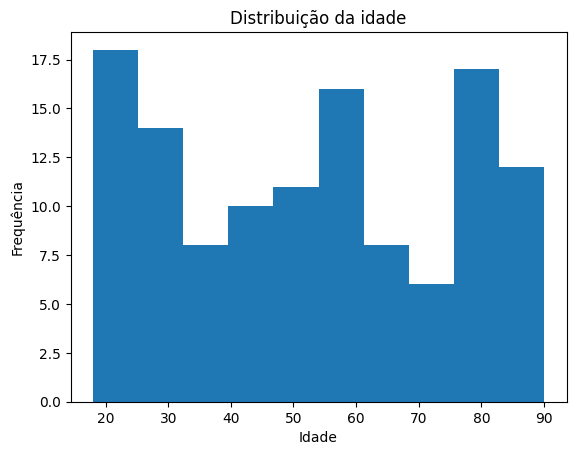

In [27]:
df["idade"].plot(kind="hist", bins=10)
plt.title("Distribuição da idade")
plt.xlabel("Idade")
plt.ylabel("Frequência")
plt.show()

In [28]:
print(f"Idade média: {df['idade'].mean():.1f} anos")
print(f"Peso médio: {df['peso_kg'].mean():.1f} kg")
print(f"Média de consultas no ano: {df['num_consultas_ano'].mean():.1f}")
print(f"Média de dias de internação: {df['dias_internacao'].mean():.1f}")

Idade média: 52.5 anos
Peso médio: 72.6 kg
Média de consultas no ano: 3.9
Média de dias de internação: 1.9


💡 **Exemplo**:
Se um paciente ficou 10 dias internado e outro 5 dias, faz sentido dizer que o primeiro ficou **o dobro** do tempo do segundo.

# 🧭 Resumo dos níveis de medida

In [29]:
resumo = pd.DataFrame({
    "Nível": ["Nominal", "Ordinal", "Intervalar", "Razão"],
    "Tem ordem?": ["Não", "Sim", "Sim", "Sim"],
    "Diferença faz sentido?": ["Não", "Parcial", "Sim", "Sim"],
    "Tem zero real?": ["Não", "Não", "Não", "Sim"],
    "Média faz sentido?": ["Não", "Com cautela", "Sim", "Sim"],
    "Exemplo": ["Tipo sanguíneo", "Nível de dor", "Temperatura °C", "Idade"]
})

resumo

,Nível,Tem ordem?,Diferença faz sentido?,Tem zero real?,Média faz sentido?,Exemplo
0,Nominal,Não,Não,Não,Não,Tipo sanguíneo
1,Ordinal,Sim,Parcial,Não,Com cautela,Nível de dor
2,Intervalar,Sim,Sim,Não,Sim,Temperatura °C
3,Razão,Sim,Sim,Sim,Sim,Idade
